# Decision Trees in Python


## 1. Libraries and setup

In [1]:
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer, make_classification
from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, cross_val_score, GridSearchCV, validation_curve
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree, export_text
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.figsize":(8,5),"axes.titleweight":"bold","grid.alpha":0.25,"axes.spines.top":False,"axes.spines.right":False})
pd.set_option("display.max_columns",100)
pd.set_option("display.float_format",lambda x:f"{x:,.3f}")

## 2. Helper functions

In [2]:
def classification_metrics(y_true,y_pred,y_probability=None,model_name="Model"):
    result={"model":model_name,"accuracy":accuracy_score(y_true,y_pred),"precision":precision_score(y_true,y_pred,zero_division=0),"recall":recall_score(y_true,y_pred,zero_division=0),"f1_score":f1_score(y_true,y_pred,zero_division=0)}
    if y_probability is not None:
        result["roc_auc"]=roc_auc_score(y_true,y_probability)
    return pd.DataFrame([result]).round(3)

def plot_confusion(y_true,y_pred,labels,title="Confusion matrix"):
    cm=confusion_matrix(y_true,y_pred)
    cm_df=pd.DataFrame(cm,index=[f"Actual {x}" for x in labels],columns=[f"Predicted {x}" for x in labels])
    plt.figure(figsize=(6,4.5))
    sns.heatmap(cm_df,annot=True,fmt="d",cmap="Blues",cbar=False)
    plt.title(title); plt.xlabel("Predicted class"); plt.ylabel("Actual class"); plt.tight_layout(); plt.show()
    return cm_df

def regression_metrics(y_true,y_pred,model_name="Model"):
    return pd.DataFrame([{"model":model_name,"MAE":mean_absolute_error(y_true,y_pred),"RMSE":mean_squared_error(y_true,y_pred)**0.5,"R2":r2_score(y_true,y_pred)}]).round(3)

## 3. Toy classification example

A Decision Tree repeatedly asks threshold questions. Each split tries to create child nodes with a purer class mix than the parent node.

In [3]:
X_toy,y_toy=make_classification(n_samples=220,n_features=2,n_redundant=0,n_informative=2,n_clusters_per_class=1,class_sep=1.25,flip_y=0.06,random_state=RANDOM_STATE)
toy_df=pd.DataFrame(X_toy,columns=["customer_value","engagement"])
toy_df["response"]=y_toy
toy_df.head()

,customer_value,engagement,response
0,1.467,1.463,1
1,1.374,-1.221,0
2,0.473,0.426,1
3,1.473,-1.196,0
4,1.884,1.928,1


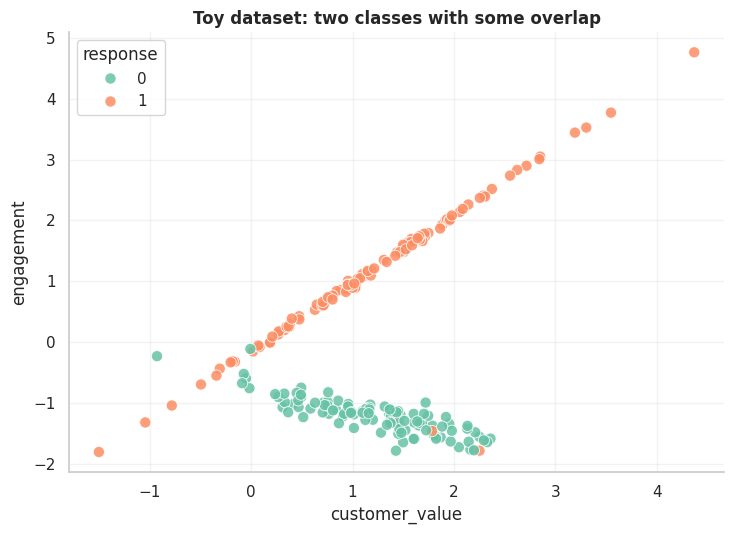

In [4]:
plt.figure(figsize=(7.5,5.5))
sns.scatterplot(data=toy_df,x="customer_value",y="engagement",hue="response",palette="Set2",s=65,alpha=.85)
plt.title("Toy dataset: two classes with some overlap")
plt.tight_layout(); plt.show()

### 3.1 Fit a shallow tree

In [5]:
Xtr,Xte,ytr,yte=train_test_split(X_toy,y_toy,test_size=.25,random_state=RANDOM_STATE,stratify=y_toy)
toy_tree=DecisionTreeClassifier(criterion="gini",max_depth=2,min_samples_leaf=8,random_state=RANDOM_STATE)
toy_tree.fit(Xtr,ytr)
pred=toy_tree.predict(Xte); proba=toy_tree.predict_proba(Xte)[:,1]
classification_metrics(yte,pred,proba,"Shallow toy tree")

,model,accuracy,precision,recall,f1_score,roc_auc
0,Shallow toy tree,0.982,0.966,1.000,0.982,0.999


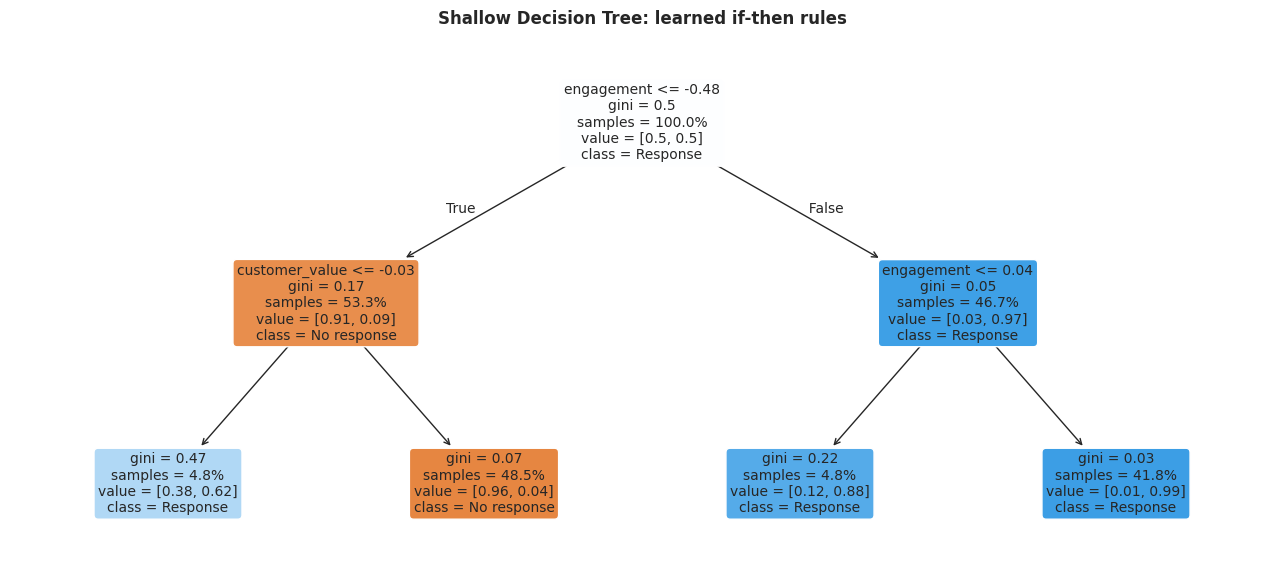

In [6]:
plt.figure(figsize=(13,6))
plot_tree(toy_tree,feature_names=["customer_value","engagement"],class_names=["No response","Response"],filled=True,rounded=True,proportion=True,precision=2,fontsize=10)
plt.title("Shallow Decision Tree: learned if-then rules")
plt.tight_layout(); plt.show()

**How to read a node:** the first line is the rule; `gini` measures class mixing; `samples` shows records reaching the node; `value` shows class proportions; and `class` is the prediction.

In [7]:
print(export_text(toy_tree,feature_names=["customer_value","engagement"],decimals=2))

|--- engagement <= -0.48
|   |--- customer_value <= -0.03
|   |   |--- class: 1
|   |--- customer_value >  -0.03
|   |   |--- class: 0
|--- engagement >  -0.48
|   |--- engagement <= 0.04
|   |   |--- class: 1
|   |--- engagement >  0.04
|   |   |--- class: 1



### 3.2 Decision regions

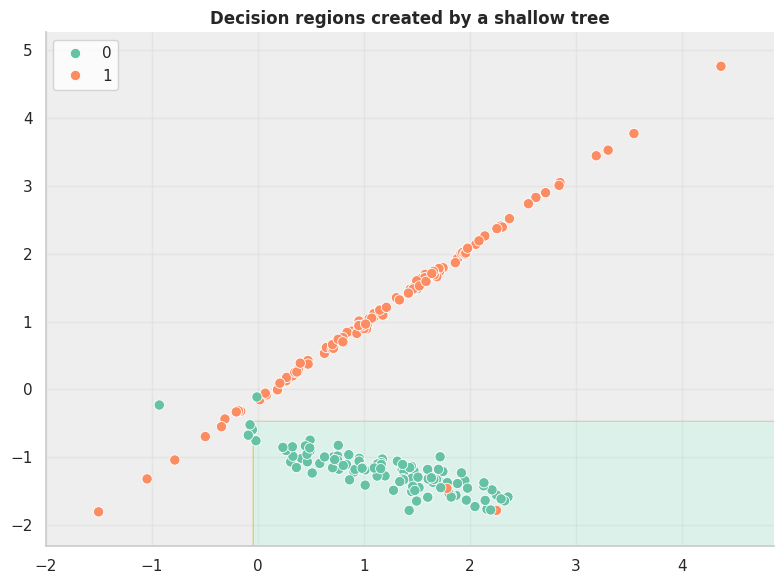

In [8]:
x0,x1=X_toy[:,0].min()-.5,X_toy[:,0].max()+.5
y0,y1=X_toy[:,1].min()-.5,X_toy[:,1].max()+.5
xx,yy=np.meshgrid(np.linspace(x0,x1,350),np.linspace(y0,y1,350))
zz=toy_tree.predict(np.c_[xx.ravel(),yy.ravel()]).reshape(xx.shape)
plt.figure(figsize=(8,6))
plt.contourf(xx,yy,zz,alpha=.22,cmap="Set2")
sns.scatterplot(x=X_toy[:,0],y=X_toy[:,1],hue=y_toy,palette="Set2",s=55,edgecolor="white")
plt.title("Decision regions created by a shallow tree")
plt.tight_layout(); plt.show()

## 4. Gini impurity and entropy

Both measures quantify class mixing. A useful split produces a strong weighted reduction in impurity.

In [9]:
def gini_impurity(counts):
    p=np.array(counts)/np.sum(counts)
    return 1-np.sum(p**2)

def entropy(counts):
    p=np.array(counts)/np.sum(counts)
    p=p[p>0]
    return -np.sum(p*np.log2(p))

mixes={"100 / 0":[100,0],"90 / 10":[90,10],"70 / 30":[70,30],"50 / 50":[50,50]}
impurity_table=pd.DataFrame([{"class_mix":k,"gini":gini_impurity(v),"entropy":entropy(v)} for k,v in mixes.items()])
impurity_table.round(3)

,class_mix,gini,entropy
0,100 / 0,0.000,-0.000
1,90 / 10,0.180,0.469
2,70 / 30,0.420,0.881
3,50 / 50,0.500,1.000


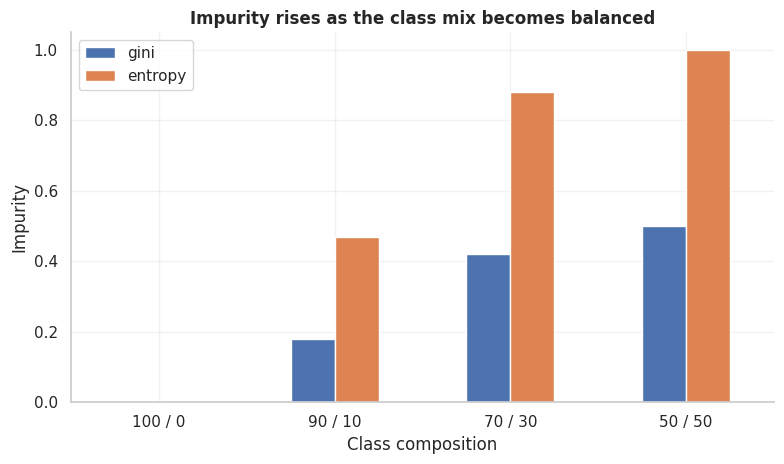

In [10]:
ax=impurity_table.set_index("class_mix")[["gini","entropy"]].plot(kind="bar",figsize=(8,4.8))
ax.set_title("Impurity rises as the class mix becomes balanced")
ax.set_xlabel("Class composition"); ax.set_ylabel("Impurity")
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

**Interpretation.** Pure nodes have impurity 0. A 50/50 binary node is maximally mixed.

## 5. Realistic classification: breast cancer diagnosis

The positive class is recoded as **malignant risk = 1**, so recall directly measures the share of malignant cases detected.

In [11]:
breast=load_breast_cancer(as_frame=True)
breast_df=breast.frame.copy()
breast_df["malignant_risk"]=(breast_df["target"]==0).astype(int)
breast_df=breast_df.drop(columns="target")
print("Shape:",breast_df.shape)
display(breast_df.head())

Shape: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,malignant_risk
0,17.990,10.380,122.800,"1,001.000",0.118,0.278,0.300,0.147,0.242,0.079,1.095,0.905,8.589,153.400,0.006,0.049,0.054,0.016,0.030,0.006,25.380,17.330,184.600,"2,019.000",0.162,0.666,0.712,0.265,0.460,0.119,1
1,20.570,17.770,132.900,"1,326.000",0.085,0.079,0.087,0.070,0.181,0.057,0.543,0.734,3.398,74.080,0.005,0.013,0.019,0.013,0.014,0.004,24.990,23.410,158.800,"1,956.000",0.124,0.187,0.242,0.186,0.275,0.089,1
2,19.690,21.250,130.000,"1,203.000",0.110,0.160,0.197,0.128,0.207,0.060,0.746,0.787,4.585,94.030,0.006,0.040,0.038,0.021,0.022,0.005,23.570,25.530,152.500,"1,709.000",0.144,0.424,0.450,0.243,0.361,0.088,1
3,11.420,20.380,77.580,386.100,0.142,0.284,0.241,0.105,0.260,0.097,0.496,1.156,3.445,27.230,0.009,0.075,0.057,0.019,0.060,0.009,14.910,26.500,98.870,567.700,0.210,0.866,0.687,0.258,0.664,0.173,1
4,20.290,14.340,135.100,"1,297.000",0.100,0.133,0.198,0.104,0.181,0.059,0.757,0.781,5.438,94.440,0.011,0.025,0.057,0.019,0.018,0.005,22.540,16.670,152.200,"1,575.000",0.137,0.205,0.400,0.163,0.236,0.077,1


In [12]:
quality=pd.DataFrame({"dtype":breast_df.dtypes.astype(str),"missing_values":breast_df.isna().sum(),"unique_values":breast_df.nunique()})
balance=breast_df["malignant_risk"].value_counts().sort_index().rename(index={0:"Benign",1:"Malignant"}).to_frame("count")
balance["percent"]=100*balance["count"]/balance["count"].sum()
display(quality.head(8)); display(balance.round(2))

,dtype,missing_values,unique_values
mean radius,float64,0,456
mean texture,float64,0,479
mean perimeter,float64,0,522
mean area,float64,0,539
mean smoothness,float64,0,474
mean compactness,float64,0,537
mean concavity,float64,0,537
mean concave points,float64,0,542


,count,percent
malignant_risk,,
Benign,357,62.740
Malignant,212,37.260


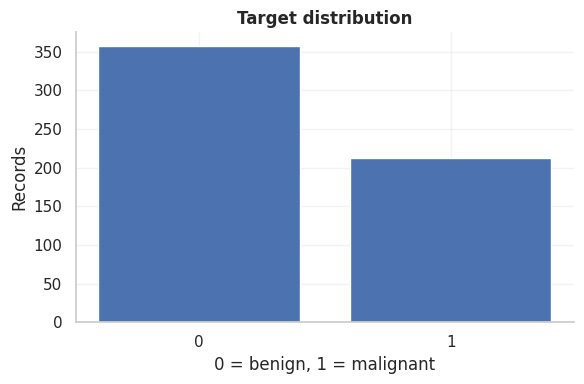

In [13]:
counts=breast_df["malignant_risk"].value_counts().sort_index()
plt.figure(figsize=(6,4))
plt.bar(counts.index.astype(str),counts.values)
plt.title("Target distribution")
plt.xlabel("0 = benign, 1 = malignant"); plt.ylabel("Records")
plt.tight_layout(); plt.show()

### 5.1 Unrestricted tree and overfitting

In [14]:
X=breast_df.drop(columns="malignant_risk"); y=breast_df["malignant_risk"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.25,random_state=RANDOM_STATE,stratify=y)
unrestricted=DecisionTreeClassifier(random_state=RANDOM_STATE).fit(X_train,y_train)
train_pred=unrestricted.predict(X_train); test_pred=unrestricted.predict(X_test); test_proba=unrestricted.predict_proba(X_test)[:,1]
pd.DataFrame({"dataset":["Training","Testing"],"accuracy":[accuracy_score(y_train,train_pred),accuracy_score(y_test,test_pred)],"tree_depth":[unrestricted.get_depth()]*2,"leaf_count":[unrestricted.get_n_leaves()]*2}).round(3)

,dataset,accuracy,tree_depth,leaf_count
0,Training,1.000,8,21
1,Testing,0.958,8,21


**Interpretation.** Near-perfect training performance with weaker test performance is a warning sign of overfitting.

### 5.2 Pre-pruning

In [15]:
controlled=DecisionTreeClassifier(criterion="gini",max_depth=4,min_samples_split=12,min_samples_leaf=6,class_weight="balanced",random_state=RANDOM_STATE).fit(X_train,y_train)
cpred=controlled.predict(X_test); cproba=controlled.predict_proba(X_test)[:,1]
comparison=pd.concat([classification_metrics(y_test,test_pred,test_proba,"Unrestricted tree"),classification_metrics(y_test,cpred,cproba,"Controlled tree")],ignore_index=True)
comparison

,model,accuracy,precision,recall,f1_score,roc_auc
0,Unrestricted tree,0.958,0.980,0.906,0.941,0.947
1,Controlled tree,0.930,0.939,0.868,0.902,0.924


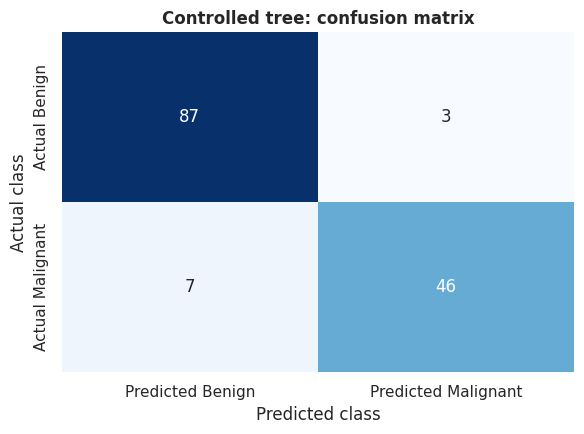

,Predicted Benign,Predicted Malignant
Actual Benign,87,3
Actual Malignant,7,46


In [16]:
plot_confusion(y_test,cpred,["Benign","Malignant"],"Controlled tree: confusion matrix")

In [17]:
print(classification_report(y_test,cpred,target_names=["Benign","Malignant"],digits=3))

              precision    recall  f1-score   support

      Benign      0.926     0.967     0.946        90
   Malignant      0.939     0.868     0.902        53

    accuracy                          0.930       143
   macro avg      0.932     0.917     0.924       143
weighted avg      0.930     0.930     0.929       143



**Business interpretation.** In screening, false negatives may be more costly than false positives, so malignant recall deserves special attention.

### 5.3 Visualize the controlled tree

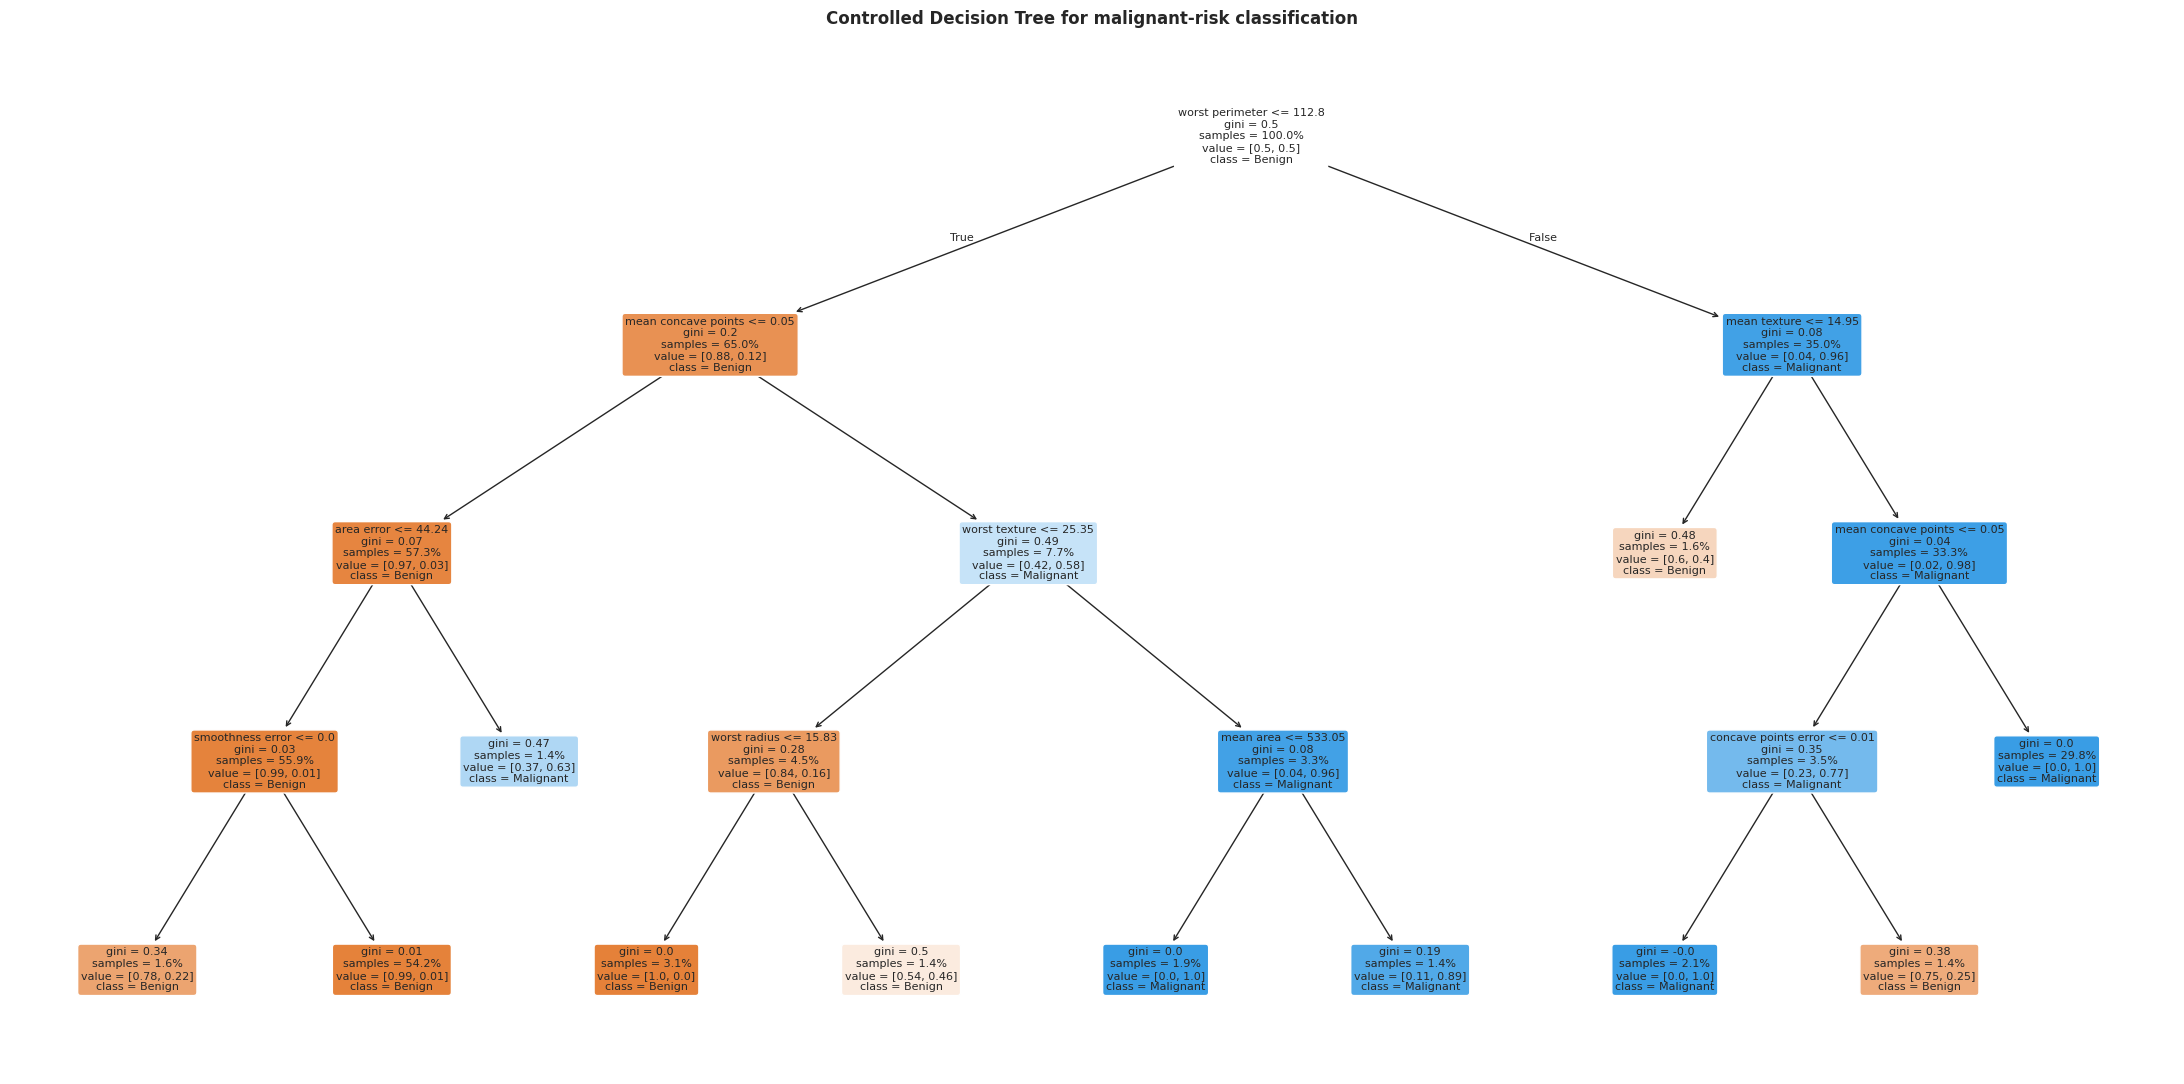

In [18]:
plt.figure(figsize=(22,11))
plot_tree(controlled,feature_names=X.columns,class_names=["Benign","Malignant"],filled=True,rounded=True,proportion=True,precision=2,fontsize=8)
plt.title("Controlled Decision Tree for malignant-risk classification")
plt.tight_layout(); plt.show()

### 5.4 Feature importance

In [19]:
importance_df=pd.DataFrame({"feature":X.columns,"importance":controlled.feature_importances_}).sort_values("importance",ascending=False)
importance_df.head(12)

,feature,importance
22,worst perimeter,0.768
7,mean concave points,0.099
21,worst texture,0.055
13,area error,0.024
1,mean texture,0.022
17,concave points error,0.021
20,worst radius,0.008
14,smoothness error,0.003
3,mean area,0.001
8,mean symmetry,0.000


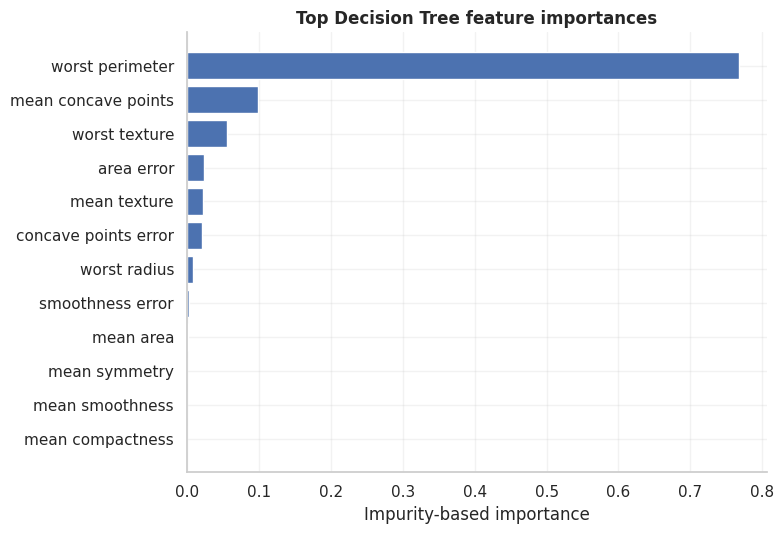

In [20]:
chart=importance_df.head(12).sort_values("importance")
plt.figure(figsize=(8,5.5))
plt.barh(chart["feature"],chart["importance"])
plt.title("Top Decision Tree feature importances")
plt.xlabel("Impurity-based importance")
plt.tight_layout(); plt.show()

### 5.5 Depth and the bias-variance trade-off

In [21]:
depths=np.arange(1,13)
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=RANDOM_STATE)
tr_scores,va_scores=validation_curve(DecisionTreeClassifier(min_samples_leaf=4,class_weight="balanced",random_state=RANDOM_STATE),X,y,param_name="max_depth",param_range=depths,scoring="f1",cv=cv,n_jobs=-1)
curve=pd.DataFrame({"max_depth":depths,"training_f1":tr_scores.mean(1),"validation_f1":va_scores.mean(1),"validation_std":va_scores.std(1)})
curve.round(3)

,max_depth,training_f1,validation_f1,validation_std
0,1,0.895,0.871,0.026
1,2,0.922,0.883,0.031
2,3,0.955,0.888,0.023
3,4,0.972,0.902,0.016
4,5,0.976,0.890,0.018
5,6,0.976,0.897,0.023
6,7,0.976,0.897,0.023
7,8,0.976,0.897,0.023
8,9,0.976,0.897,0.023
9,10,0.976,0.897,0.023


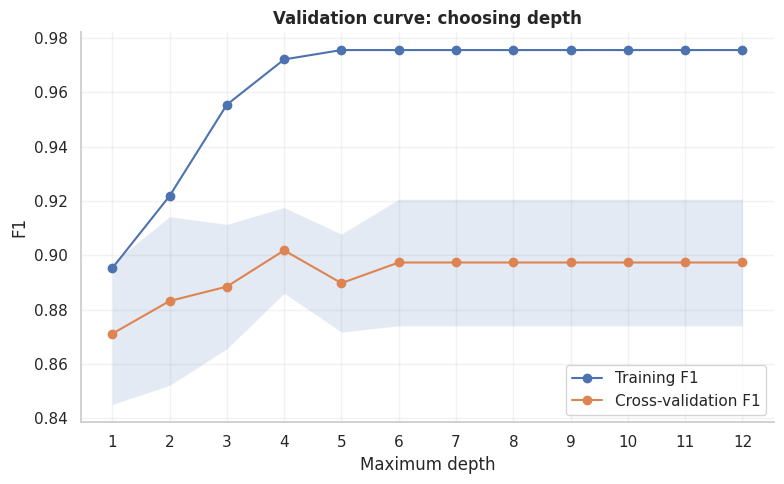

In [22]:
plt.figure(figsize=(8,5))
plt.plot(curve.max_depth,curve.training_f1,marker="o",label="Training F1")
plt.plot(curve.max_depth,curve.validation_f1,marker="o",label="Cross-validation F1")
plt.fill_between(curve.max_depth,curve.validation_f1-curve.validation_std,curve.validation_f1+curve.validation_std,alpha=.15)
plt.xticks(depths); plt.xlabel("Maximum depth"); plt.ylabel("F1")
plt.title("Validation curve: choosing depth"); plt.legend(); plt.tight_layout(); plt.show()

### 5.6 Grid search

In [23]:
grid={"criterion":["gini","entropy"],"max_depth":[2,3,4,5,6,None],"min_samples_leaf":[2,4,6,10,15],"ccp_alpha":[0,.002,.005,.01]}
search=GridSearchCV(DecisionTreeClassifier(class_weight="balanced",random_state=RANDOM_STATE),grid,scoring="f1",cv=cv,n_jobs=-1,return_train_score=True).fit(X_train,y_train)
print("Best parameters:",search.best_params_)
print("Best CV F1:",round(search.best_score_,3))

Best parameters: {'ccp_alpha': 0.01, 'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 2}
Best CV F1: 0.922


In [24]:
best=search.best_estimator_
bpred=best.predict(X_test); bproba=best.predict_proba(X_test)[:,1]
final_results=pd.concat([comparison,classification_metrics(y_test,bpred,bproba,"Tuned tree")],ignore_index=True)
final_results

,model,accuracy,precision,recall,f1_score,roc_auc
0,Unrestricted tree,0.958,0.980,0.906,0.941,0.947
1,Controlled tree,0.930,0.939,0.868,0.902,0.924
2,Tuned tree,0.930,0.957,0.849,0.900,0.937


### 5.7 Cost-complexity pruning

In [25]:
path=DecisionTreeClassifier(class_weight="balanced",random_state=RANDOM_STATE).cost_complexity_pruning_path(X_train,y_train)
rows=[]
for alpha in path.ccp_alphas[:-1]:
    model=DecisionTreeClassifier(class_weight="balanced",random_state=RANDOM_STATE,ccp_alpha=alpha)
    scores=cross_val_score(model,X_train,y_train,cv=cv,scoring="f1",n_jobs=-1)
    model.fit(X_train,y_train)
    rows.append({"ccp_alpha":alpha,"mean_cv_f1":scores.mean(),"std_cv_f1":scores.std(),"depth":model.get_depth(),"leaves":model.get_n_leaves()})
pruning_df=pd.DataFrame(rows)
pruning_df.sort_values("mean_cv_f1",ascending=False).head(10).round(4)

,ccp_alpha,mean_cv_f1,std_cv_f1,depth,leaves
7,0.003,0.909,0.023,5,13
8,0.004,0.909,0.023,5,12
13,0.007,0.907,0.029,3,6
11,0.005,0.906,0.022,4,8
12,0.006,0.906,0.022,3,7
9,0.005,0.906,0.022,4,11
10,0.005,0.906,0.022,4,10
0,0.000,0.906,0.028,7,25
1,0.000,0.906,0.028,7,24
2,0.000,0.906,0.028,6,23


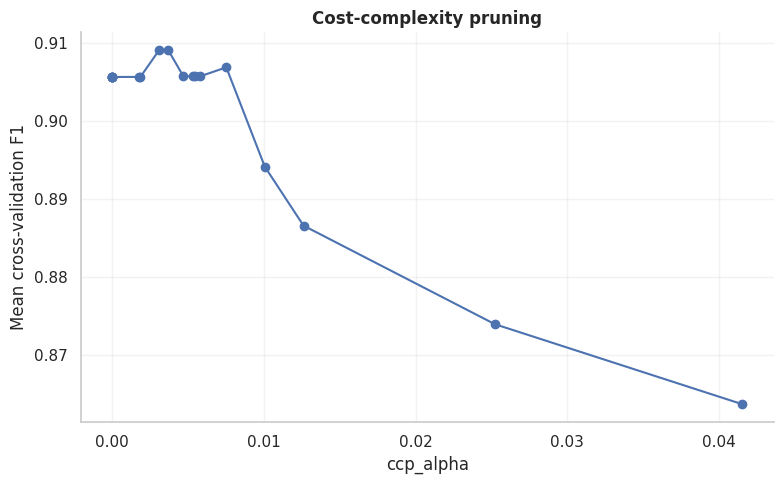

In [26]:
plt.figure(figsize=(8,5))
plt.plot(pruning_df.ccp_alpha,pruning_df.mean_cv_f1,marker="o")
plt.title("Cost-complexity pruning")
plt.xlabel("ccp_alpha"); plt.ylabel("Mean cross-validation F1")
plt.tight_layout(); plt.show()

**Practical note.** A slightly simpler tree near the best score can be preferable when interpretability, stability, or governance matters.

## Common mistakes and practical pitfalls

1. Evaluating only on training data.
2. Using accuracy as the only classification metric.
3. Growing a tree too large to interpret.
4. Treating feature importance as causality.
5. Ignoring correlated predictors.
6. Using IDs or addresses as predictors.
7. Tuning on the final test set.
8. Scaling unnecessarily.
9. Ignoring data drift.
10. Over-interpreting exact thresholds without business review.